# Feature Importance Analysis

**Research questions addressed:**  
> RQ2: Which eBPF features contribute most to improved detection?  

**Split usage in this notebook:**
- Load the **saved Split 4 headline artifact from Notebook 01** for each feature set.
- Use **sampled rows from Split 4 `test_realistic.parquet`** for all expensive interpretability steps so the notebook stays stable.
- Treat feature-group ablation as a **lightweight inference-time masking diagnostic**, not as a new training result.

**Methods:**
1. **Permutation importance** on a sampled Split 4 realistic test set (model-agnostic, ROC-AUC drop)
2. **Feature-group ablation** on a sampled Split 4 realistic test set via inference-time masking
3. **SHAP** on a very small sampled matrix

**Prerequisite:** Run `00_data_preparation.ipynb` and `01_baseline_vs_ebpf.ipynb` first  
(models from Notebook 01 must exist in `data/models/`).


In [1]:
import os, sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

HERE = Path.cwd().resolve()
REPO_ROOT = None
for _p in [HERE] + list(HERE.parents):
    if (_p / 'ml').exists() and (_p / 'data').exists():
        REPO_ROOT = _p
        break
assert REPO_ROOT
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from ml.notebooks.experiment_config import *
from ml.notebooks.modeling_pipeline import (
    load_model_pack,
    prepare_split,
    align_to_features,
    binary_metrics,
)

PERMUTATION_SAMPLE_N = 3000
PERMUTATION_REPEATS = 3
SHAP_SAMPLE_N = 512
SHAP_BACKGROUND_N = 64
ABLATION_SAMPLE_N = 3000

FI_DIR = REPORTS_DIR / 'feature_importance' / f'seed{RANDOM_SEED}'
FI_DIR.mkdir(parents=True, exist_ok=True)
print('[*] Output:', FI_DIR)


[*] Output: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/feature_importance/seed42


## Setup: Load saved headline artifacts and sampled realistic test matrices

In [2]:
PACKS = {
    'baseline': load_model_pack('baseline', artifact='headline', seed=RANDOM_SEED),
    'ebpf': load_model_pack('ebpf', artifact='headline', seed=RANDOM_SEED),
}

SPLIT4 = {'baseline': SPLITS_4_BASELINE, 'ebpf': SPLITS_4_EBPF}

def sample_prepared_split(df: pd.DataFrame, feature_list, sample_n: int, seed: int = RANDOM_SEED):
    if len(df) > sample_n:
        df = df.sample(n=sample_n, random_state=seed)
    prep = prepare_split(df, feature_list=feature_list)
    return align_to_features(prep.X, feature_list), prep.y

DATA = {}
for fs in ['baseline', 'ebpf']:
    feat = PACKS[fs]['features']
    te_real_df = pd.read_parquet(SPLIT4[fs] / 'test_realistic.parquet')
    Xperm, yperm = sample_prepared_split(te_real_df, feat, sample_n=PERMUTATION_SAMPLE_N, seed=RANDOM_SEED)
    Xablate, yablate = sample_prepared_split(te_real_df, feat, sample_n=ABLATION_SAMPLE_N, seed=RANDOM_SEED + 1)
    Xshap, yshap = sample_prepared_split(te_real_df, feat, sample_n=SHAP_SAMPLE_N, seed=RANDOM_SEED)

    DATA[fs] = {
        'Xperm': Xperm, 'yperm': yperm,
        'Xablate': Xablate, 'yablate': yablate,
        'Xshap': Xshap, 'yshap': yshap,
        'realistic_rows': int(len(te_real_df)),
        'features': feat,
    }
    del te_real_df
    print(
        f"[*] {fs}: selected={PACKS[fs]['selected_model_name']} "
        f"features={len(feat)} realistic_rows={DATA[fs]['realistic_rows']:,} "
        f"perm_sample={len(DATA[fs]['Xperm']):,} ablation_sample={len(DATA[fs]['Xablate']):,} shap_sample={len(DATA[fs]['Xshap']):,}"
    )


[*] baseline: selected=hgb_balanced features=10 realistic_rows=546,207 perm_sample=3,000 ablation_sample=3,000 shap_sample=512
[*] ebpf: selected=hgb_balanced features=17 realistic_rows=546,207 perm_sample=3,000 ablation_sample=3,000 shap_sample=512


## Method 1: Permutation importance on a sampled realistic test set

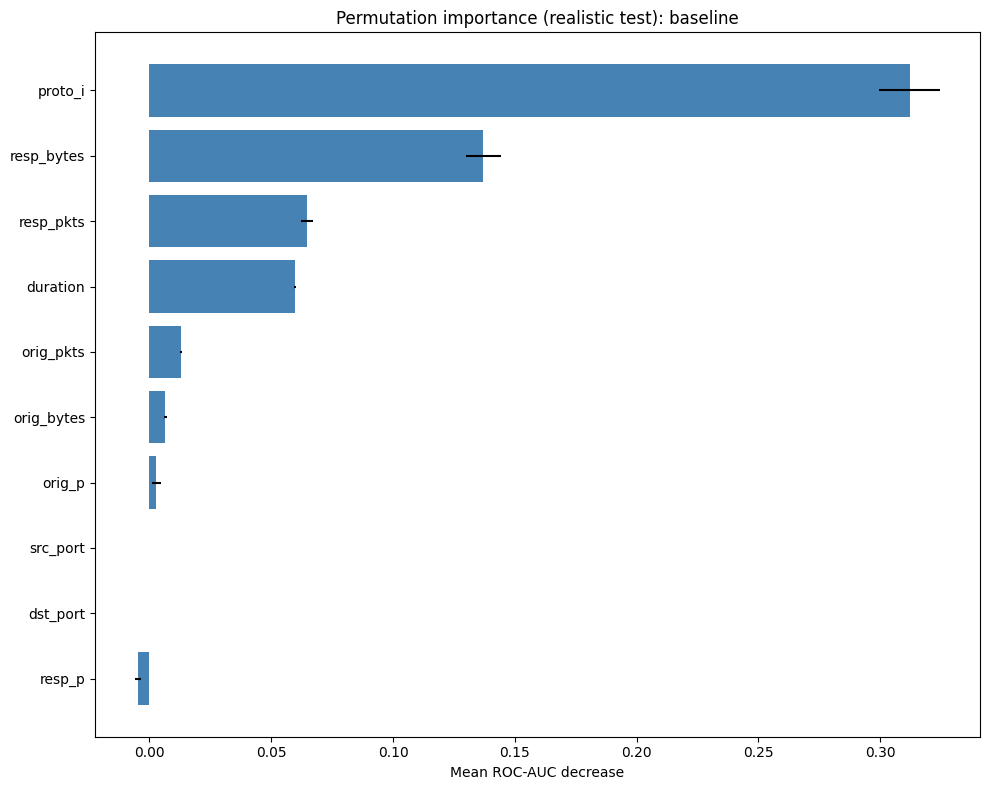

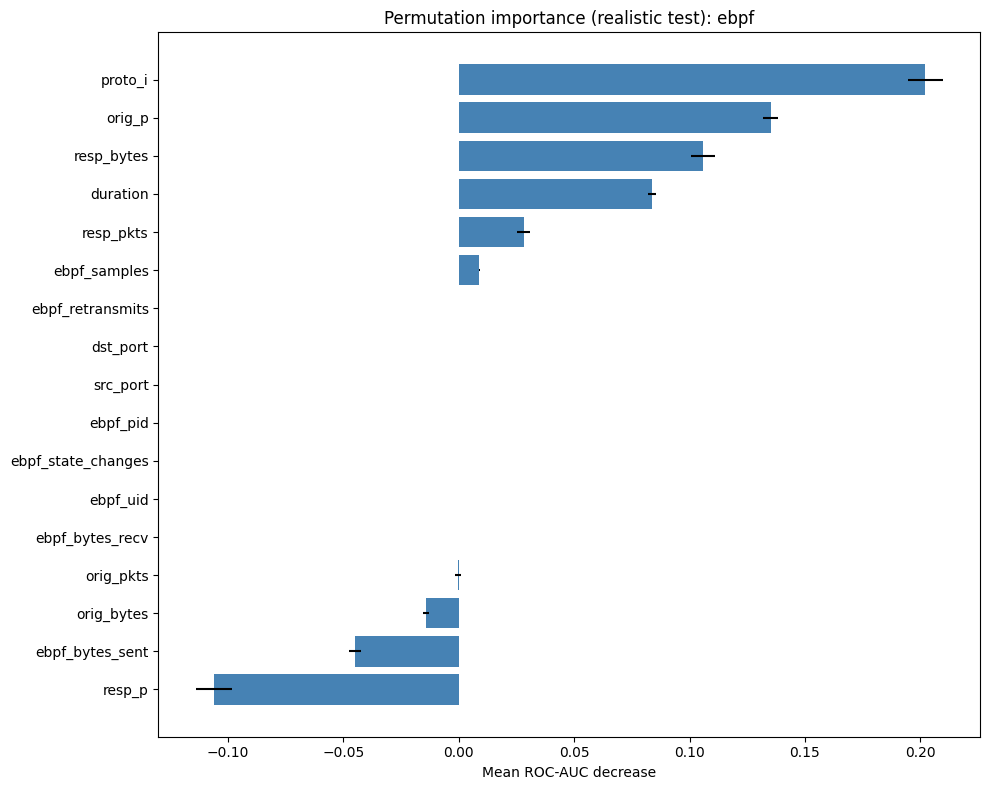

In [3]:
def run_permutation(fs_name: str, sample_n: int = PERMUTATION_SAMPLE_N, n_repeats: int = PERMUTATION_REPEATS):
    pack = PACKS[fs_name]
    model = pack['model']
    d = DATA[fs_name]

    X = d['Xperm']
    y = d['yperm']

    pi = permutation_importance(
        model,
        X,
        y,
        scoring='roc_auc',
        n_repeats=n_repeats,
        random_state=RANDOM_SEED,
        n_jobs=1,
    )
    imp = pd.DataFrame({
        'feature': d['features'],
        'importance_mean': pi.importances_mean,
        'importance_std': pi.importances_std,
    }).sort_values('importance_mean', ascending=False)

    imp.to_csv(FI_DIR / f'permutation_{fs_name}.csv', index=False)

    top = imp.head(25).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top['feature'], top['importance_mean'], xerr=top['importance_std'], color='steelblue')
    ax.set_title(f'Permutation importance (realistic test): {fs_name}')
    ax.set_xlabel('Mean ROC-AUC decrease')
    plt.tight_layout()
    plt.savefig(FI_DIR / f'permutation_{fs_name}.png', dpi=150)
    plt.show()

    return imp

IMP_BASE = run_permutation('baseline')
IMP_EBPF = run_permutation('ebpf')


## Method 2: Lightweight feature-group ablation on a sampled realistic test set

  variant        model  n_features  roc_auc_realistic  f1_realistic  recall_realistic  precision_realistic
      all hgb_balanced          17             0.7224        0.5018            0.3558               0.8515
zeek_only hgb_balanced          10             0.6942        0.4782            0.3558               0.7289
ebpf_only hgb_balanced           7             0.4826        0.4883            0.6786               0.3814


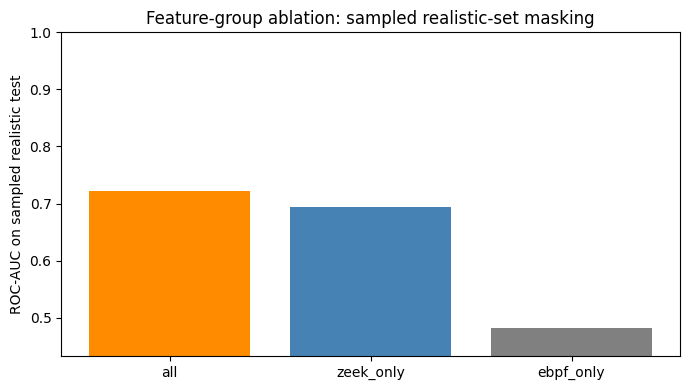

In [4]:
# Lightweight eBPF contribution ablation on the saved headline model.
# This avoids retraining multiple models on full Split 4 data.
# We measure the drop from the sampled realistic-set baseline after
# zeroing selected feature groups at inference time.
EBPF_HINTS = ('ebpf', 'bpf', 'pid', 'ppid', 'uid', 'gid', 'comm', 'exe', 'cmd', 'sock', 'sk_', 'tcp_', 'udp_', 'netns', 'inode', 'tgid')

fs = 'ebpf'
d = DATA[fs]
pack = PACKS[fs]

feat_all = d['features']
feat_zeek = [f for f in feat_all if not any(h in f.lower() for h in EBPF_HINTS)]
feat_ebpf_only = [f for f in feat_all if any(h in f.lower() for h in EBPF_HINTS)]

X_base = d['Xablate'].copy()
y_base = d['yablate']
score_base = pack['model'].predict_proba(X_base)[:, 1] if hasattr(pack['model'], 'predict_proba') else pack['model'].decision_function(X_base)
if np.ndim(score_base) != 1:
    score_base = score_base[:, 1]
pred_base = (score_base >= pack.get('threshold', 0.5)).astype(int)
base_metrics = binary_metrics(y_base, pred_base, score_base)

rows = [{
    'variant': 'all',
    'model': pack['selected_model_name'],
    'n_features': len(feat_all),
    'roc_auc_realistic': base_metrics['roc_auc'],
    'f1_realistic': base_metrics['f1'],
    'recall_realistic': base_metrics['recall'],
    'precision_realistic': base_metrics['precision'],
}]

for name, feats in [('all', feat_all), ('zeek_only', feat_zeek), ('ebpf_only', feat_ebpf_only)]:
    if not feats or name == 'all':
        continue
    X_masked = X_base.copy()
    drop_cols = [c for c in feat_all if c not in feats]
    X_masked.loc[:, drop_cols] = 0.0
    score = pack['model'].predict_proba(X_masked)[:, 1] if hasattr(pack['model'], 'predict_proba') else pack['model'].decision_function(X_masked)
    if np.ndim(score) != 1:
        score = score[:, 1]
    pred = (score >= pack.get('threshold', 0.5)).astype(int)
    metrics = binary_metrics(y_base, pred, score)
    rows.append({
        'variant': name,
        'model': pack['selected_model_name'],
        'n_features': len(feats),
        'roc_auc_realistic': metrics['roc_auc'],
        'f1_realistic': metrics['f1'],
        'recall_realistic': metrics['recall'],
        'precision_realistic': metrics['precision'],
    })

ab_df = pd.DataFrame(rows).sort_values('roc_auc_realistic', ascending=False)
print(ab_df.to_string(index=False, float_format='{:.4f}'.format))
ab_df.to_csv(FI_DIR / 'ebpf_ablation_realistic.csv', index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ab_df['variant'], ab_df['roc_auc_realistic'], color=['darkorange', 'steelblue', 'grey'][:len(ab_df)])
ax.set_ylim(max(0, ab_df['roc_auc_realistic'].min() - 0.05), 1.0)
ax.set_ylabel('ROC-AUC on sampled realistic test')
ax.set_title('Feature-group ablation: sampled realistic-set masking')
plt.tight_layout()
plt.savefig(FI_DIR / 'ebpf_ablation_realistic.png', dpi=150)
plt.show()


## Method 3: SHAP Feature Importance

SHAP values explain each feature's contribution to individual predictions. We use `shap.TreeExplainer` for the HGB model (exact, fast) and fall back to `KernelExplainer` for other model types.

[*] Computing SHAP values for baseline (512 samples)...
  Top 5 SHAP features (baseline): ['proto_i', 'resp_bytes', 'resp_p', 'resp_pkts', 'duration']


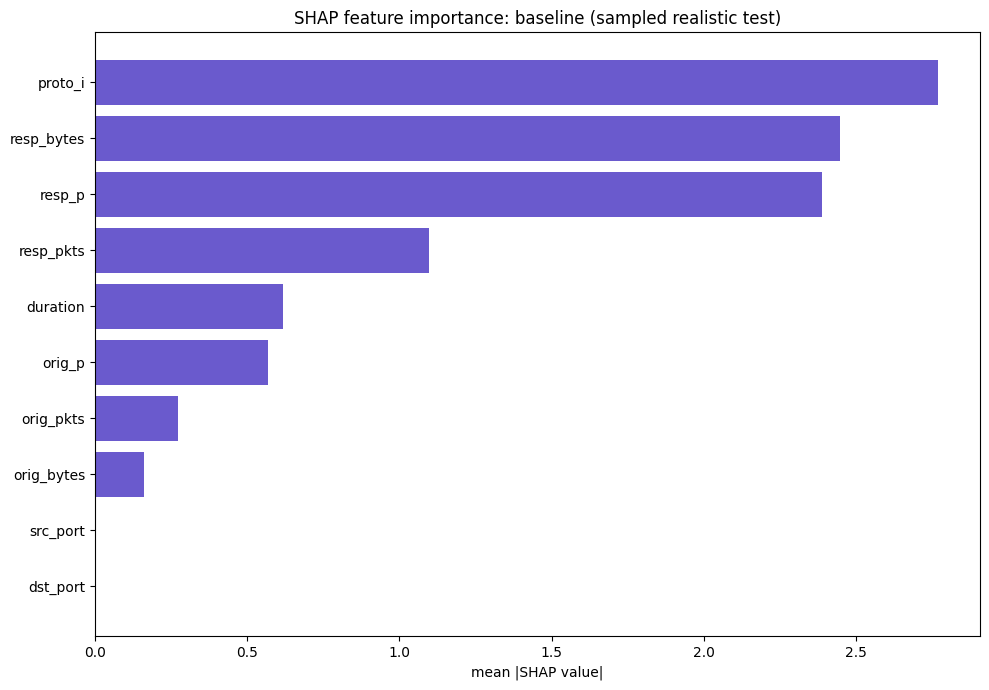

  Saved: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/feature_importance/seed42/shap_bar_baseline.png
[*] Computing SHAP values for ebpf (512 samples)...
  Top 5 SHAP features (ebpf): ['resp_p', 'orig_p', 'resp_bytes', 'proto_i', 'resp_pkts']


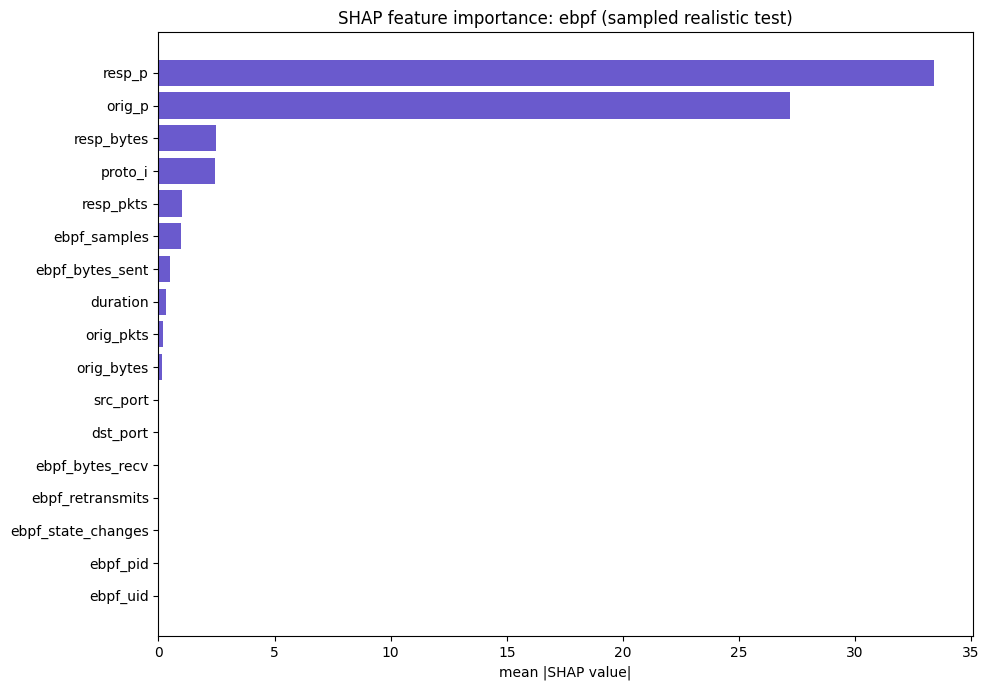

  Saved: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/feature_importance/seed42/shap_bar_ebpf.png

[+] SHAP analysis complete.


In [5]:
import shap

def prepare_shap_inputs(model, X_df: pd.DataFrame):
    if hasattr(model, 'named_steps') and 'clf' in model.named_steps:
        clf = model.named_steps['clf']
        if len(model.steps) > 1:
            X_proc = model[:-1].transform(X_df)
        else:
            X_proc = X_df.to_numpy()
        return clf, np.asarray(X_proc), list(X_df.columns)
    return model, X_df.to_numpy(), list(X_df.columns)

for fs_name in ['baseline', 'ebpf']:
    pack = PACKS[fs_name]
    d = DATA[fs_name]
    X_shap = d['Xshap']
    print(f'[*] Computing SHAP values for {fs_name} ({len(X_shap)} samples)...')

    expl_model, X_proc, feature_names = prepare_shap_inputs(pack['model'], X_shap)
    background = X_proc[: min(SHAP_BACKGROUND_N, len(X_proc))]
    selected = pack.get('selected_model_name', '')

    if any(tag in selected for tag in ('hgb', 'rf', 'et')) or 'forest' in str(type(expl_model)).lower() or 'gradient' in str(type(expl_model)).lower():
        explainer = shap.TreeExplainer(expl_model)
        shap_values = explainer.shap_values(X_proc)
    elif 'logreg' in selected or 'logistic' in str(type(expl_model)).lower():
        explainer = shap.LinearExplainer(expl_model, background)
        shap_values = explainer.shap_values(X_proc)
    else:
        print(f'  [*] Falling back to KernelExplainer for {selected or type(expl_model).__name__}')
        explainer = shap.KernelExplainer(
            lambda x: pack['model'].predict_proba(pd.DataFrame(x, columns=feature_names))[:, 1],
            pd.DataFrame(background, columns=feature_names),
        )
        shap_values = explainer.shap_values(X_shap, nsamples=min(128, 2 * len(feature_names) + 16))

    if isinstance(shap_values, list):
        shap_values = shap_values[-1]

    mean_shap = np.abs(shap_values).mean(axis=0)
    shap_df = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_shap}).sort_values('mean_abs_shap', ascending=False)
    shap_df.head(20).to_csv(FI_DIR / f'shap_top20_{fs_name}.csv', index=False)
    print(f'  Top 5 SHAP features ({fs_name}): {shap_df.head(5).feature.tolist()}')

    top = shap_df.head(20).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(top['feature'], top['mean_abs_shap'], color='slateblue')
    ax.set_title(f'SHAP feature importance: {fs_name} (sampled realistic test)')
    ax.set_xlabel('mean |SHAP value|')
    plt.tight_layout()
    out = FI_DIR / f'shap_bar_{fs_name}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {out}')

print('\n[+] SHAP analysis complete.')
